## Loading the Resized data after the Preprocessing

The preprocessed images after preprocessing stored in google drive are loaded here for the next steps.

In [ ]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Step 2: Set the path to the saved preprocessed data
load_path = '/content/drive/MyDrive/Preprocessed_MWD/'

The images are verified by displaying the shape of labels and images

In [ ]:
# Step 3: Load the images and labels
import numpy as np
import os

images = np.load(os.path.join(load_path, 'images.npy'))
labels = np.load(os.path.join(load_path, 'labels.npy'))

# Step 4: Verify the loaded data
print(f"Loaded images shape: {images.shape}")
print(f"Loaded labels shape: {labels.shape}")

Loaded images shape: (1122, 128, 128, 3)
Loaded labels shape: (1122,)


Few images and their classes are displayed to see if the images are loaded to the colab file or not.

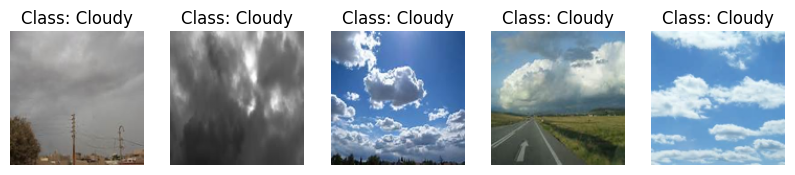

In [ ]:
import matplotlib.pyplot as plt
# Step 6: Preview a few images
def preview_images(images, labels, num_images=5):
    plt.figure(figsize=(10, 10))
    classes = ["Cloudy", "Rain", "Shine", "Sunrise"]

    for i in range(num_images):
        ax = plt.subplot(1, num_images, i + 1)
        plt.imshow(images[i])
        plt.title(f"Class: {classes[labels[i]]}")
        plt.axis("off")

    plt.show()

preview_images(images, labels)

## Splitting the dataset

The unique class labels present in the dataset are displayed to verify the distinct categories and to ensure that labels are correctly assigned during preprocessing.

In [ ]:
print("Unique labels:", np.unique(labels))


Unique labels: [0 1 2 3]


The dataset is split into training, validation, and test sets while maintaining class balance using stratified sampling.

In [ ]:
from sklearn.model_selection import train_test_split

try:
    # Splitting the dataset
    X_train, X_temp, y_train, y_temp = train_test_split(
        images, labels, test_size=0.4, stratify=labels, random_state=42
    )
    print("Training set shape:", X_train.shape, y_train.shape)
    print("Temp set shape:", X_temp.shape, y_temp.shape)

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
    )
    print("Validation set shape:", X_val.shape, y_val.shape)
    print("Test set shape:", X_test.shape, y_test.shape)

except ValueError as e:
    print("Error during split:", e)


Training set shape: (673, 128, 128, 3) (673,)
Temp set shape: (449, 128, 128, 3) (449,)
Validation set shape: (224, 128, 128, 3) (224,)
Test set shape: (225, 128, 128, 3) (225,)


The function visualizes the class distribution for the training, validation, and test sets. It calculates the number of images in each class using a counter and plots a bar chart to show the distribution.

Training Set Class Distribution: Counter({3: 213, 0: 180, 2: 152, 1: 128})


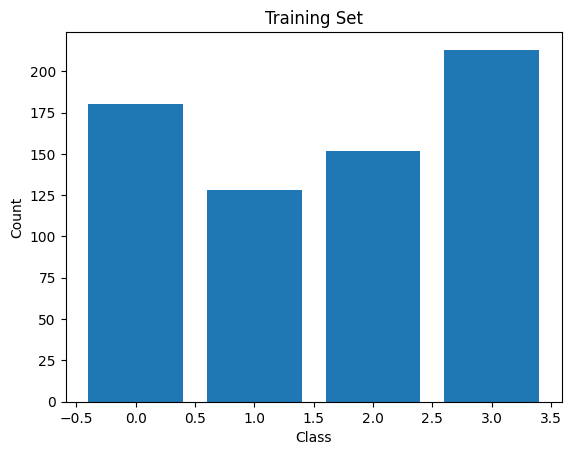

Validation Set Class Distribution: Counter({3: 71, 0: 60, 2: 50, 1: 43})


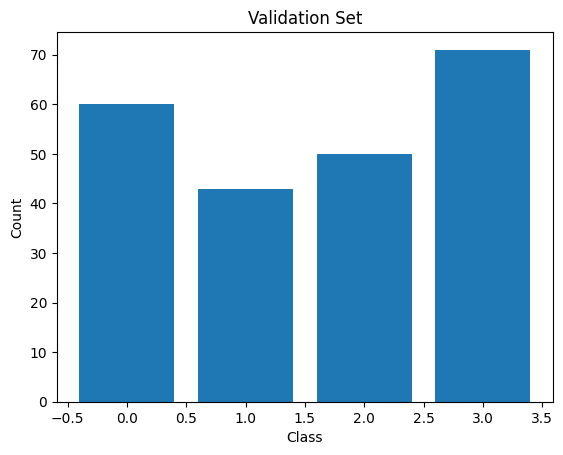

Test Set Class Distribution: Counter({3: 72, 0: 60, 2: 51, 1: 42})


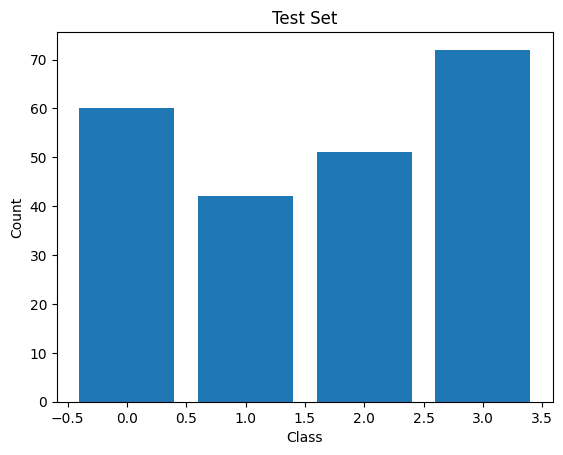

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

def plot_class_distribution(labels, title):
    class_counts = Counter(labels)
    print(f"{title} Class Distribution: {class_counts}")

    classes = list(class_counts.keys())
    counts = list(class_counts.values())

    plt.bar(classes, counts)
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.title(title)
    plt.show()

plot_class_distribution(y_train, "Training Set")
plot_class_distribution(y_val, "Validation Set")
plot_class_distribution(y_test, "Test Set")


The code converts the class labels into one-hot encoding, transforming each label with a length equal to the number of classes (4 in this case)

In [ ]:
from tensorflow.keras.utils import to_categorical

# Convert labels to one-hot encoding
y_train_one_hot = to_categorical(y_train, num_classes=4)
y_val_one_hot = to_categorical(y_val, num_classes=4)
y_test_one_hot = to_categorical(y_test, num_classes=4)

# Print shape to verify
print("One-hot encoded training labels shape:", y_train_one_hot.shape)
print("One-hot encoded validation labels shape:", y_val_one_hot.shape)
print("One-hot encoded test labels shape:", y_test_one_hot.shape)


One-hot encoded training labels shape: (673, 4)
One-hot encoded validation labels shape: (224, 4)
One-hot encoded test labels shape: (225, 4)


## ResNet-50 model

Importing necessary libraries to build a ResNet - 50 model

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

Data generators are prepared for the training, validation, and test datasets to handle data efficiently in batches with a batch size of 16.

In [ ]:
# Step 1: Prepare Data Generators
train_datagen = ImageDataGenerator()
val_datagen = ImageDataGenerator()
test_datagen = ImageDataGenerator()

train_generator = train_datagen.flow(X_train, y_train_one_hot, batch_size=16)
val_generator = val_datagen.flow(X_val, y_val_one_hot, batch_size=16)
test_generator = test_datagen.flow(X_test, y_test_one_hot, batch_size=16, shuffle=False)


The ResNet-50 model is loaded with pre-trained weights excluding the top layer, and the input shape is set to (128, 128, 3). The dense layer with 1024 units , Relu activation is added.

In [ ]:
# Step 2: Load Pretrained ResNet-50
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Global average pooling
x = Dense(1024, activation='relu')(x)  # Fully connected layer
predictions = Dense(4, activation='softmax')(x)  # Output layer for 4 classes

model = Model(inputs=base_model.input, outputs=predictions)

# Freeze base model layers for transfer learning
for layer in base_model.layers:
    layer.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


The model is compiled using Adam optimizer with a learning rate of 0.001 and categorical cross entropy as the loss function. The evaluation metric is accuracy.

In [ ]:
# Step 3: Compile the Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy']
)


The model is trained upto 20 epochs with early stopping and learning rate scheduler.Early stopping stops training if the validation loss doesn't improve for 5 epochs. The learning rate scheduler reduces learning rate by 0.1 if validation loss stagnates for 3 epochs.

In [ ]:
# Step 4: Training with Early Stopping and Learning Rate Scheduler
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


43/43 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.2747 - loss: 1.4841 - val_accuracy: 0.3304 - val_loss: 1.3442 - learning_rate: 0.0010
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.3227 - loss: 1.3778 - val_accuracy: 0.3527 - val_loss: 1.3400 - learning_rate: 0.0010
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.4334 - loss: 1.3252 - val_accuracy: 0.2812 - val_loss: 1.3940 - learning_rate: 0.0010
Epoch 4/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.3371 - loss: 1.3587 - val_accuracy: 0.4420 - val_loss: 1.2622 - learning_rate: 0.0010
Epoch 5/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.4558 - loss: 1.2717 - val_accuracy: 0.4062 - val_loss: 1.2771 - learning_rate: 0.0010
Epoch 6/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.4792 - loss: 1.1877 - val_accuracy: 0.3571 - val_loss: 1.3094 - learning_rate: 0.0010
Epoch 7/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.4078 - loss: 1.2271 - val_accuracy: 0.3482 - va

The model is evaluated on the metrics - test loss and test accuracy.

In [ ]:
# Step 5: Evaluate on Test Set
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.4789 - loss: 1.1770
Test Loss: 1.1565462350845337, Test Accuracy: 0.4888888895511627


The training history is visualized by plotting accuracy over epochs for both training and validation datasets

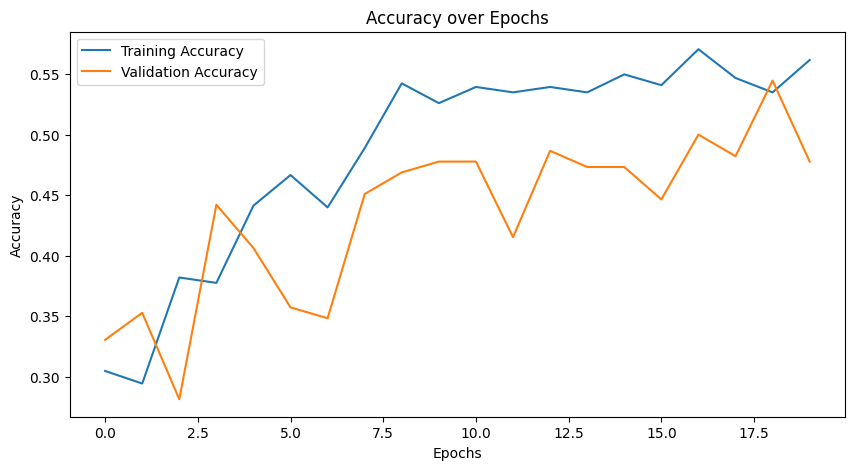

In [ ]:
# Step 6: Visualize Training History
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()




The training history is visualized by plotting the loss over epochs for both training and validation datasets.

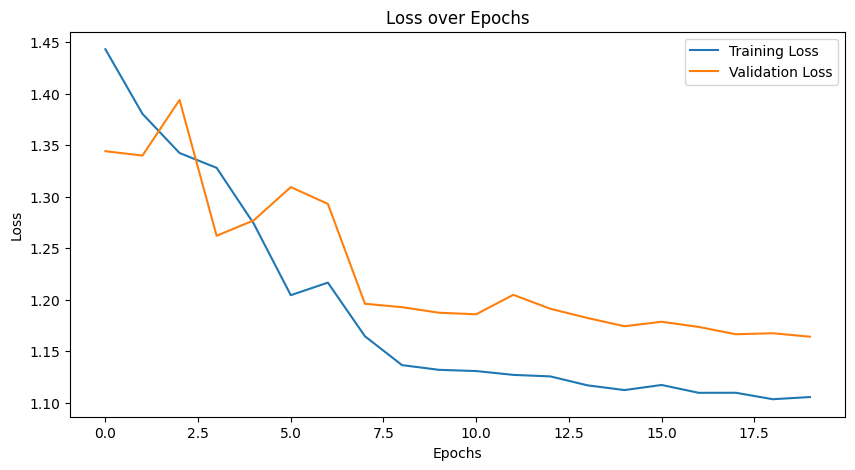

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

The true labels are extracted from the test set by converting one-hot encoded labels into class indices. A confusion matrix is generated and a classification report is created with metrics like precision, recall, and F1-score for each class, using class-specific labels for clarity

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Predict on the test set
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class indices

# Extract true labels from the test generator
y_true = np.argmax(y_test_one_hot, axis=1)  # Convert one-hot encoded labels to class indices

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
print("Confusion Matrix:\n", cm)

# Classification Report
class_labels = ['Class 0', 'Class 1', 'Class 2', 'Class 3']  # Replace with your actual class names
print("Classification Report:\n", classification_report(y_true, y_pred_classes, target_names=class_labels))


15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step
Confusion Matrix:
 [[24  0  0 36]
 [ 7 10  0 25]
 [11  1 12 27]
 [ 4  0  4 64]]
Classification Report:
               precision    recall  f1-score   support

     Class 0       0.52      0.40      0.45        60
     Class 1       0.91      0.24      0.38        42
     Class 2       0.75      0.24      0.36        51
     Class 3       0.42      0.89      0.57        72

    accuracy                           0.49       225
   macro avg       0.65      0.44      0.44       225
weighted avg       0.61      0.49      0.46       225



The ResNet model's performance : Class 3 stands out with a high recall (89%) but low precision (42%). Class 1, in contrast, has good precision (91%) but very low recall (24%). Classes 0 and 2 have moderate precision but have less recall, which is lowering their F1-scores. Overall, it has an accuracy of 49%.

## **Custom CNN model**


The code imports necessary libraries and modules for building and evaluating a custom CNN model

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


A custom CNN model is created with an input shape of (128,128,3) , three convolutional layers with 32,64,128 filters each using a (3,3) kernel and ReLU activation. The max pooling layers size is (2,2). A flatten layer, dense layers with 128 units and ReLU activation and a dropout layer with a rate of 0.5 for regularization. Finally an output layer with softmax activation.

In [ ]:
def create_custom_cnn(input_shape=(128, 128, 3), num_classes=4):
    model1 = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model1


The custom CNN model is compiled using the Adam optimizer with a learning rate of 0.001, categorical cross-entropy as the loss function , early stopping (patience=5) , learning rate reduction (factor=0.1, patience=3) and 20 epochs.

In [ ]:
# Create the model
model1 = create_custom_cnn()

# Compile the model
model1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy']
)

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3)

# Train the model
history = model1.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stopping, reduce_lr]
)


Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


43/43 ━━━━━━━━━━━━━━━━━━━━ 28s 615ms/step - accuracy: 0.4541 - loss: 1.1665 - val_accuracy: 0.7009 - val_loss: 0.6766 - learning_rate: 0.0010
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 25s 589ms/step - accuracy: 0.7102 - loss: 0.6811 - val_accuracy: 0.7634 - val_loss: 0.5897 - learning_rate: 0.0010
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 24s 553ms/step - accuracy: 0.7992 - loss: 0.5433 - val_accuracy: 0.8170 - val_loss: 0.5010 - learning_rate: 0.0010
Epoch 4/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 27s 635ms/step - accuracy: 0.7893 - loss: 0.5353 - val_accuracy: 0.8705 - val_loss: 0.4272 - learning_rate: 0.0010
Epoch 5/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 37s 552ms/step - accuracy: 0.8479 - loss: 0.4262 - val_accuracy: 0.7946 - val_loss: 0.4396 - learning_rate: 0.0010
Epoch 6/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 24s 562ms/step - accuracy: 0.8505 - loss: 0.4337 - val_accuracy: 0.8304 - val_loss: 0.5176 - learning_rate: 0.0010
Epoch 7/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 26s 603ms/step - accuracy: 0.8494 - loss: 0.3629 - val_

The custom CNN model is evaluated on the test set using test loss and test accuracy

In [ ]:
# Evaluate the model on the test set
test_loss, test_accuracy = model1.evaluate(test_generator)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step - accuracy: 0.8915 - loss: 0.3223
Test Loss: 0.3432188928127289
Test Accuracy: 0.8799999952316284



The training and validation accuracy over epochs are visualized to analyze the model's performance.

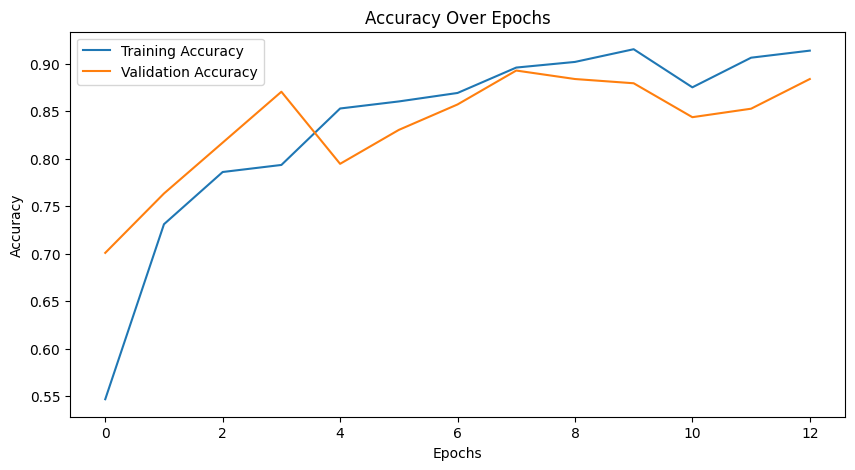

In [ ]:
# Plot accuracy
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


The training and validation loss over epochs are visualized.

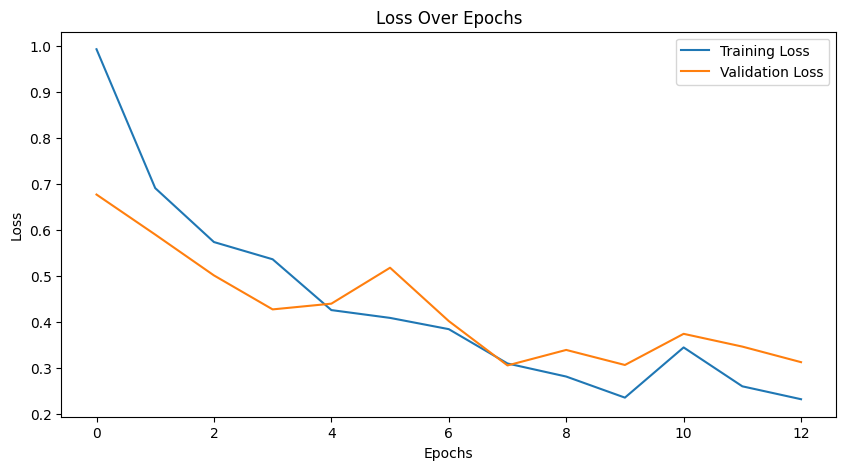

In [ ]:
# Plot loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

The model's predictions on the test set are converted from probabilities to class indices. The true labels are extracted by decoding the one-hot encoded test labels. A confusion matrix is generated to compare the true and predicted labels and a classification report is created with metrics such as precision, recall, and F1-score for each class

In [ ]:
# Predict on the test set
y_pred = model1.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class indices
y_true = np.argmax(y_test_one_hot, axis=1)  # Convert one-hot encoded labels to class indices

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
print("Confusion Matrix:\n", cm)

# Classification Report
class_labels = ['Class 0', 'Class 1', 'Class 2', 'Class 3']  # Replace with your actual class names
report = classification_report(y_true, y_pred_classes, target_names=class_labels)
print("Classification Report:\n", report)

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 190ms/step
Confusion Matrix:
 [[45  6  9  0]
 [ 3 37  2  0]
 [ 0  3 48  0]
 [ 1  0  3 68]]
Classification Report:
               precision    recall  f1-score   support

     Class 0       0.92      0.75      0.83        60
     Class 1       0.80      0.88      0.84        42
     Class 2       0.77      0.94      0.85        51
     Class 3       1.00      0.94      0.97        72

    accuracy                           0.88       225
   macro avg       0.87      0.88      0.87       225
weighted avg       0.89      0.88      0.88       225



The model has an accuracy of 88%. Class 3 excels with perfect precision 100% and high recall 94%, contributing to its outstanding F1-score 97%. Class 2 performs well with high recall 94% , a F1-score 85% and recall 88% and F1-score 84%. Class 0, while having good precision 92%, struggles a bit with recall 75%, slightly lowering its F1-score 83%. The weighted averages indicate consistent performance across all classes.

The confusion matrix is visualized using a heatmap to provide a clear and detailed view of the model's performance

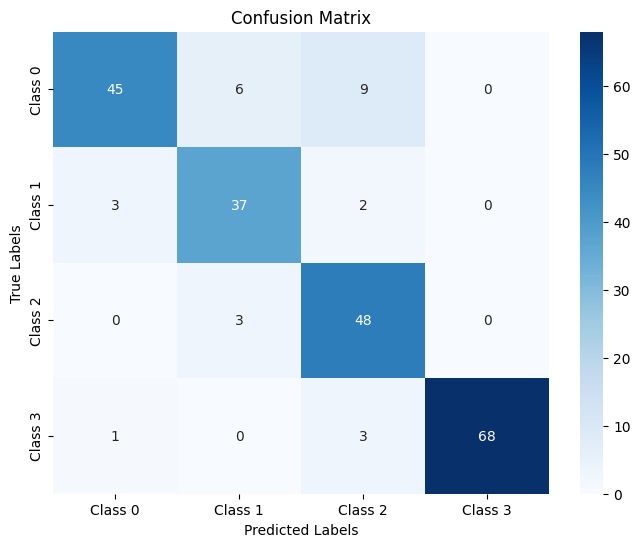

In [ ]:
# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

## **ResNet-50 vs Custom CNN**

This code compares the performance of the ResNet and Custom CNN models by calculating metrics such as accuracy, precision, recall, and F1-score using weighted averages. Predictions are converted into class indices for both models, and true labels are extracted from the one-hot encoded test labels.

In [ ]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import pandas as pd

# Collect metrics for ResNet (model)
y_pred_resnet = model.predict(test_generator)
y_pred_classes_resnet = np.argmax(y_pred_resnet, axis=1)
y_true_resnet = np.argmax(y_test_one_hot, axis=1)

resnet_accuracy = accuracy_score(y_true_resnet, y_pred_classes_resnet)
resnet_precision, resnet_recall, resnet_f1, _ = precision_recall_fscore_support(
    y_true_resnet, y_pred_classes_resnet, average='weighted'
)

# Collect metrics for Custom CNN (model1)
y_pred_cnn = model1.predict(test_generator)
y_pred_classes_cnn = np.argmax(y_pred_cnn, axis=1)
y_true_cnn = np.argmax(y_test_one_hot, axis=1)

cnn_accuracy = accuracy_score(y_true_cnn, y_pred_classes_cnn)
cnn_precision, cnn_recall, cnn_f1, _ = precision_recall_fscore_support(
    y_true_cnn, y_pred_classes_cnn, average='weighted'
)

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Model': ['ResNet', 'Custom CNN'],
    'Accuracy': [resnet_accuracy, cnn_accuracy],
    'Precision': [resnet_precision, cnn_precision],
    'Recall': [resnet_recall, cnn_recall],
    'F1-Score': [resnet_f1, cnn_f1]
})

# Display the comparison table
print(comparison_df)


15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 909ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step
        Model  Accuracy  Precision    Recall  F1-Score
0      ResNet  0.488889   0.613564  0.488889  0.455246
1  Custom CNN  0.880000   0.890527  0.880000  0.880577


This code visualizes the performance comparison between the ResNet and Custom CNN models using a bar chart. It plots metrics like accuracy, precision, recall, and F1-score.

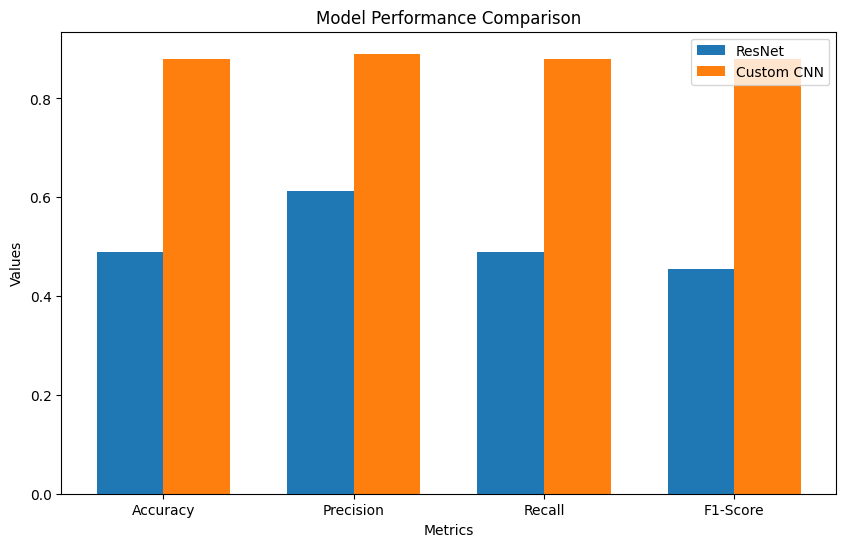

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
resnet_values = [resnet_accuracy, resnet_precision, resnet_recall, resnet_f1]
cnn_values = [cnn_accuracy, cnn_precision, cnn_recall, cnn_f1]

x = np.arange(len(metrics))  # Label locations
width = 0.35  # Bar width

# Plot bar chart
plt.figure(figsize=(10, 6))
plt.bar(x - width/2, resnet_values, width, label='ResNet')
plt.bar(x + width/2, cnn_values, width, label='Custom CNN')

# Add labels and title
plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Model Performance Comparison')
plt.xticks(x, metrics)
plt.legend()

# Display the plot
plt.show()


The custom CNN model seems to perform better on this dataset than the ResNet-50 dataset.

## **Testing ResNet-50 and custom CNN Models on new Images**

In the next few steps I have loaded new test images one for each class and preprocessed them to match the input requirements of the models. I have used both the models to classify the images. The predictions are displayed with the input image , model name and the predicted class.

### **Testing Rain class**

In [ ]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

# Function to load and preprocess the image
def preprocess_image(image_path, target_size=(128, 128)):
    # Load the image
    img = load_img(image_path, target_size=target_size)  # Resize to match model input size
    img_array = img_to_array(img)  # Convert to array
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = img_array / 255.0  # Normalize pixel values to [0, 1]
    return img, img_array

# Example usage
image_path = "/content/drive/MyDrive/photo.jpg"  # Replace with your image path
original_image, preprocessed_image = preprocess_image(image_path)


In [ ]:
import matplotlib.pyplot as plt

# Display the image and predict the class
def classify_and_display_image(model, original_image, preprocessed_image, class_labels):
    # Step 1: Display the image
    plt.imshow(original_image)  # Use the original_image returned from preprocess_image
    plt.axis('off')
    plt.title("Input Image")
    plt.show()

    # Step 2: Predict the class
    predictions = model.predict(preprocessed_image)  # Use preprocessed_image for prediction
    predicted_class = np.argmax(predictions, axis=1)[0]  # Get the class index
    predicted_class_name = class_labels[predicted_class]  # Map to class name

    print(f"Predicted Class: {predicted_class_name}")  # Print the prediction



Custom CNN Prediction:


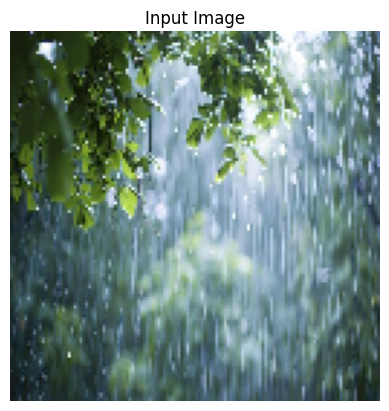

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step
Predicted Class: rain


In [ ]:
# Define class labels
class_labels = ['cloudy', 'rain', 'shine', 'sunrise']  # Replace with your actual class names
print("Custom CNN Prediction:")
# Call the function to display the image and classify
classify_and_display_image(model1, original_image, preprocessed_image, class_labels)

ResNet Prediction:


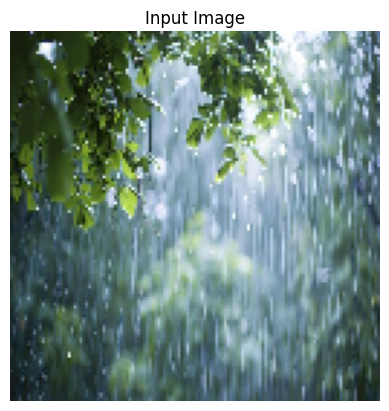

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Predicted Class: rain


In [ ]:
# Preprocess the new image
original_image, preprocessed_image = preprocess_image(image_path)
print("ResNet Prediction:")
# Display the new image and classify it
classify_and_display_image(model1, original_image, preprocessed_image, class_labels)

Both the models were able to identify the class rain correctly

### **Testing Sunrise class**

Custom CNN Prediction:


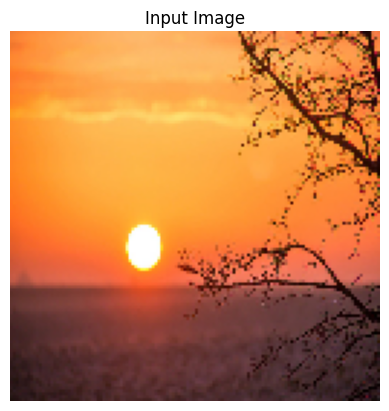

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Predicted Class: sunrise


In [ ]:
# Path to the new test image
image_path2 = "/content/drive/MyDrive/photo2.jpg"  # Replace with your new image path

# Preprocess the new image
original_image, preprocessed_image = preprocess_image(image_path2)
print("Custom CNN Prediction:")
# Display the new image and classify it
classify_and_display_image(model1, original_image, preprocessed_image, class_labels)



ResNet Prediction:


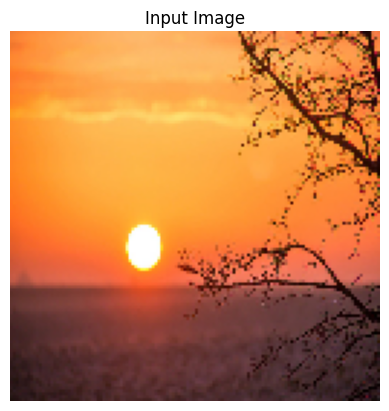

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted Class: shine


In [ ]:
# Define class labels
class_labels = ['cloudy', 'rain', 'shine', 'sunrise']  # Replace with your actual class names
print("ResNet Prediction:")
# Call the function to display the image and classify
classify_and_display_image(model, original_image, preprocessed_image, class_labels)

Custom CNN model was able to identify the class correctly as sunrise while the ResNet-50 model was not able to identify.

### **Testing Shine class**

Custom CNN Prediction:


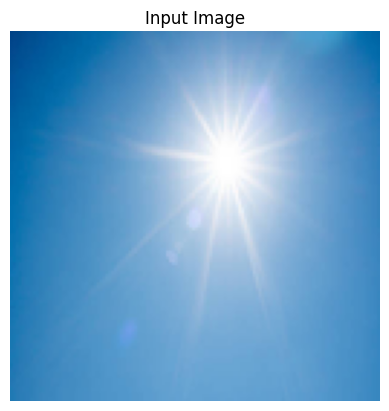

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Predicted Class: shine


In [ ]:
# Path to the new test image
image_path3 = "/content/drive/MyDrive/images2.jpg"  # Replace with your new image path

# Preprocess the new image
original_image, preprocessed_image = preprocess_image(image_path3)
print("Custom CNN Prediction:")
# Display the new image and classify it
classify_and_display_image(model1, original_image, preprocessed_image, class_labels)

ResNet Prediction:


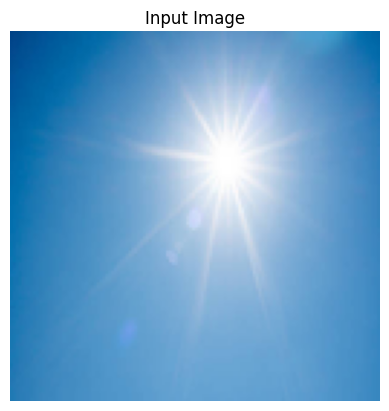

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
Predicted Class: sunrise


In [ ]:
# Define class labels
class_labels = ['cloudy', 'rain', 'shine', 'sunrise']  # Replace with your actual class names
print("ResNet Prediction:")
# Call the function to display the image and classify
classify_and_display_image(model, original_image, preprocessed_image, class_labels)

The ResNet was not able to predict the shine class correctly but the Custom CNN model was able to identify it accurately.

### **Testing cloudy class**

Custom CNN Prediction:


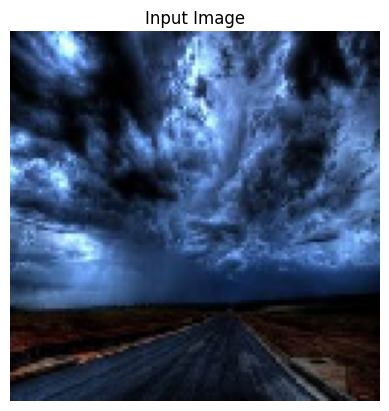

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicted Class: cloudy


In [ ]:
# Path to the new test image
image_path4 = "/content/drive/MyDrive/image4.jpg"  # Replace with your new image path

# Preprocess the new image
original_image, preprocessed_image = preprocess_image(image_path4)
print("Custom CNN Prediction:")
# Display the new image and classify it
classify_and_display_image(model1, original_image, preprocessed_image, class_labels)

ResNet Prediction:


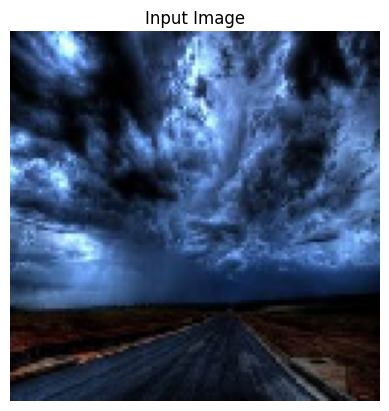

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
Predicted Class: cloudy


In [ ]:
# Define class labels
class_labels = ['cloudy', 'rain', 'shine', 'sunrise']  # Replace with your actual class names
print("ResNet Prediction:")
# Call the function to display the image and classify
classify_and_display_image(model, original_image, preprocessed_image, class_labels)

Both the models were able to identify the cloudy class correctly.

Overall, the ResNet model was able to identify only 2 classes correctly, while Custom CNN model was able to identify all the classes correctly.

## **Cross Validation**

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np


This function performs stratified k-fold cross-validation to evaluate a model's performance. The dataset is split into 5 folds, compiled using the Adam optimizer and categorical cross-entropy loss, and trained on the training split.

In [ ]:
def cross_validate_model(model_fn, X, y, class_labels, n_splits=5):
    """
    Perform stratified k-fold cross-validation for a given model.

    Parameters:
    - model_fn: Function to create a new model instance.
    - X: Input data (images).
    - y: Labels (one-hot encoded or class indices).
    - class_labels: List of class names.
    - n_splits: Number of folds for cross-validation.

    Returns:
    - metrics: Dictionary of average metrics across folds.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    metrics = {'accuracy': [], 'precision': [], 'recall': [], 'f1_score': []}

    for train_idx, val_idx in skf.split(X, np.argmax(y, axis=1)):  # Use class indices for stratification
        # Split data into training and validation
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # Create a new model instance
        model = model_fn()

        # Compile the model
        model.compile(
            optimizer='adam',
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        # Train the model
        model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=10,
            batch_size=16,
            verbose=0  # Suppress training logs for brevity
        )

        # Evaluate the model on the validation set
        y_pred = model.predict(X_val)
        y_pred_classes = np.argmax(y_pred, axis=1)
        y_true = np.argmax(y_val, axis=1)

        # Compute metrics
        acc = accuracy_score(y_true, y_pred_classes)
        prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred_classes, average='weighted')

        metrics['accuracy'].append(acc)
        metrics['precision'].append(prec)
        metrics['recall'].append(rec)
        metrics['f1_score'].append(f1)

    # Aggregate metrics
    avg_metrics = {metric: (np.mean(values), np.std(values)) for metric, values in metrics.items()}

    return avg_metrics


This function creates a custom CNN model with an input shape of (128,128,3) , output layer with 4 units. The architecture includes three convolutional layers with 32, 64, and 128 filters, fully connected dense layer with 128 units and ReLU activation, along with a dropout layer with a rate of 0.5 to prevent overfitting.

In [ ]:
def create_custom_cnn(input_shape=(128, 128, 3), num_classes=4):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model


The labels are verified to check if preprocessing is necessary and then cross validation is performed. The average metrics are printed.

In [ ]:
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import StratifiedKFold
import numpy as np

# Check if labels are one-hot encoded, if not, convert them
if len(y.shape) == 1:  # If y is 1D, convert to one-hot encoding
    num_classes = len(np.unique(y))
    y_one_hot = to_categorical(y, num_classes=num_classes)
    print("One-hot encoded labels shape:", y_one_hot.shape)
else:
    y_one_hot = y  # If already one-hot encoded, no need for conversion

# Define class labels (modify as per your dataset)
class_labels = ["Cloudy", "Rain", "Shine", "Sunrise"]

# Perform cross-validation
n_splits = 5  # Number of splits for cross-validation
avg_metrics = cross_validate_model(create_custom_cnn, X, y_one_hot, class_labels, n_splits=n_splits)

# Print average metrics
print("Average metrics across folds:")
for metric, (mean, std) in avg_metrics.items():
    print(f"{metric.capitalize()}: Mean = {mean:.4f}, Std = {std:.4f}")

One-hot encoded labels shape: (1122, 4)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 241ms/step


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 242ms/step


...

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 268ms/step


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 266ms/step


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 270ms/step
Average metrics across folds:
Accuracy: Mean = 0.8476, Std = 0.0147
Precision: Mean = 0.8642, Std = 0.0143
Recall: Mean = 0.8476, Std = 0.0147
F1_score: Mean = 0.8457, Std = 0.0150


The Cross Validation metrics infer that the model correctly classifies about 84.76% of the instances on average. A standard deviation of 0.0147 indicates consistent performance across folds.On average, when the model predicts a positive class, 86.42% of those predictions are correct. The model identifies 84.76% of actual positive cases on average, with performance consistency indicated by the standard deviation.The harmonic mean of precision and recall is 84.57%.